In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm

stats = pd.read_csv('data/processed/sku_statistics.csv')
print(stats.head())

   store  item  mean_demand  std_demand  min_demand  max_demand
0      1     1    19.971522    6.741022           4          50
1      1     2    53.148959   15.005779          13         115
2      1     3    33.208105   10.072529           8          70
3      1     4    19.956188    6.640618           4          43
4      1     5    16.612815    5.672102           3          37


In [2]:
def calculate_safety_stock(std_demand, lead_time_days, service_level=0.95):
    z = norm.ppf(service_level)          # e.g. 95% service level -> z ≈ 1.65
    std_lead_time = std_demand * np.sqrt(lead_time_days)
    return z * std_lead_time

LEAD_TIME_DAYS = 7      # assumed supplier lead time
SERVICE_LEVEL = 0.95    # 95% chance of not stocking out

stats['safety_stock'] = calculate_safety_stock(stats['std_demand'], LEAD_TIME_DAYS, SERVICE_LEVEL)
stats['reorder_point'] = (stats['mean_demand'] * LEAD_TIME_DAYS) + stats['safety_stock']
stats[['safety_stock','reorder_point']] = stats[['safety_stock','reorder_point']].round(1)

print(stats.head(10))

   store  item  mean_demand  std_demand  min_demand  max_demand  safety_stock  \
0      1     1    19.971522    6.741022           4          50          29.3   
1      1     2    53.148959   15.005779          13         115          65.3   
2      1     3    33.208105   10.072529           8          70          43.8   
3      1     4    19.956188    6.640618           4          43          28.9   
4      1     5    16.612815    5.672102           3          37          24.7   
5      1     6    53.060789   14.826416          17         104          64.5   
6      1     7    52.783680   15.073838          14         115          65.6   
7      1     8    69.472070   18.751980          24         137          81.6   
8      1     9    46.504929   13.247496          14          94          57.7   
9      1    10    66.354326   18.283007          16         131          79.6   

   reorder_point  
0          169.1  
1          437.3  
2          276.3  
3          168.6  
4          14

In [3]:
import os
os.makedirs('data/processed', exist_ok=True)
stats.to_csv('data/processed/replenishment_table.csv', index=False)
print(f"Saved replenishment table for {len(stats)} SKUs")

Saved replenishment table for 500 SKUs


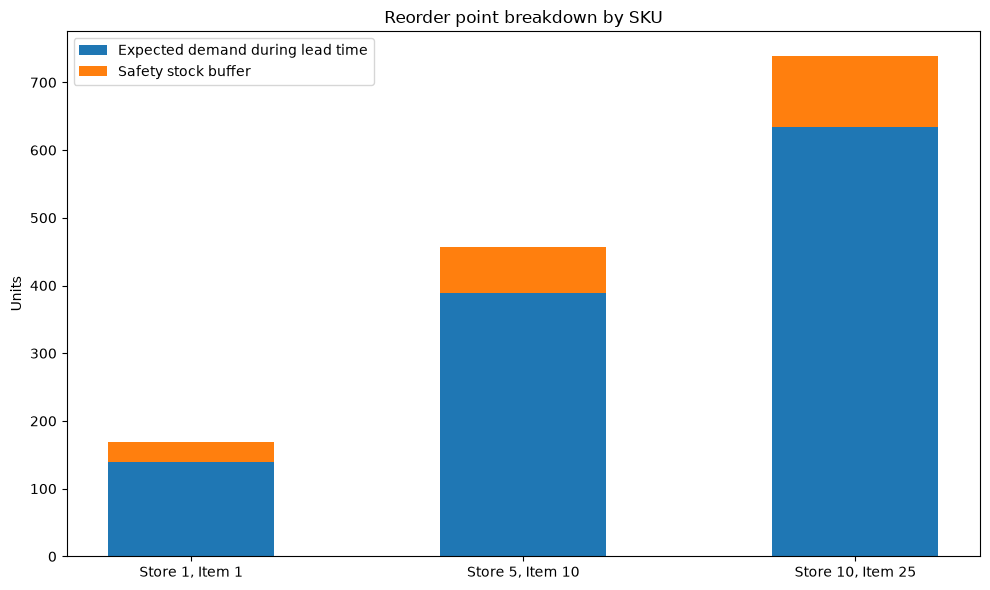

In [4]:
import matplotlib.pyplot as plt

selected = [(1, 1), (5, 10), (10, 25)]
subset = stats[stats.apply(lambda r: (r['store'], r['item']) in selected, axis=1)]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(subset))
width = 0.5

expected_demand = subset['mean_demand'] * LEAD_TIME_DAYS
ax.bar(x, expected_demand, width, label='Expected demand during lead time')
ax.bar(x, subset['safety_stock'], width, bottom=expected_demand, label='Safety stock buffer')

ax.set_xticks(x)
ax.set_xticklabels([f"Store {r.store}, Item {r.item}" for r in subset.itertuples()])
ax.set_ylabel('Units')
ax.set_title('Reorder point breakdown by SKU')
ax.legend()
plt.tight_layout()
plt.show()